# Latent Football Skill Discovery with Factor Analysis

## Objective

The objective of this notebook is to discover hidden football skill dimensions
from correlated FIFA 22 player attributes.

Factor Analysis is used to investigate whether observed attributes such as
finishing, passing, tackling, pace and strength can be represented by a
smaller number of latent abilities.

The notebook will:

- select outfield player skill attributes;
- estimate the number of factors using parallel analysis;
- fit Factor Analysis with Varimax rotation;
- interpret factors through their strongest loadings;
- identify players who strongly represent each factor;
- compare factor scores across playing positions;
- evaluate communalities and reconstruction error.

Player position is not used to discover the factors. It is used afterwards
to determine whether the discovered structure is meaningful.

In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import set_config
from sklearn.decomposition import FactorAnalysis, PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
set_config(display="text")

RANDOM_STATE = 42

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
dataset_path = Path(kagglehub.dataset_download("stefanoleone992/fifa-22-complete-player-dataset"))
csv_files = list(dataset_path.rglob("players_22.csv"))

data_path = csv_files[0]
players_df = pd.read_csv(data_path, low_memory=False)

print(f"Dataset path: {data_path}")
print(f"Dataset shape: {players_df.shape}")

players_df.head()

100%|██████████| 109M/109M [00:21<00:00, 5.32MB/s] 

Extracting files...


Dataset path: C:\Users\ADMIN\.cache\kagglehub\datasets\stefanoleone992\fifa-22-complete-player-dataset\versions\3\players_22.csv
Dataset shape: (19239, 110)


,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png


In [3]:
players_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19239 entries, 0 to 19238
Columns: 110 entries, sofifa_id to nation_flag_url
dtypes: float64(16), int64(44), object(50)
memory usage: 16.1+ MB


### Initial dataset observations

The FIFA 22 dataset contains **19,239 players and 110 variables**. It combines player identifiers, club and nationality information, financial variables, physical measurements, overall ratings, position-specific ratings, and detailed football skills.

The raw dataset contains both numerical and categorical variables. Some optional metadata fields are incomplete, but all skill variables selected for the latent-factor analysis are available without missing values.

Because the objective is to uncover underlying outfield playing abilities, descriptive variables such as player name, position, overall rating, club, and value are retained only for interpretation. They are not included as inputs to the factor model.

In [4]:
skill_attributes = [
    "attacking_crossing", "attacking_finishing", "attacking_heading_accuracy",
    "attacking_short_passing", "attacking_volleys", "skill_dribbling",
    "skill_curve", "skill_fk_accuracy", "skill_long_passing",
    "skill_ball_control", "movement_acceleration", "movement_sprint_speed",
    "movement_agility", "movement_reactions", "movement_balance",
    "power_shot_power", "power_jumping", "power_stamina", "power_strength",
    "power_long_shots", "mentality_aggression", "mentality_interceptions",
    "mentality_positioning", "mentality_vision", "mentality_penalties",
    "mentality_composure", "defending_marking_awareness",
    "defending_standing_tackle", "defending_sliding_tackle"
]

available_attributes = [column for column in skill_attributes if column in players_df.columns]
missing_attributes = sorted(set(skill_attributes) - set(available_attributes))

print(f"Available skill attributes: {len(available_attributes)}")
print("Missing requested attributes:", missing_attributes)

Available skill attributes: 29
Missing requested attributes: []


In [5]:
metadata_columns = [
    "short_name", "long_name", "age", "nationality_name", "club_name",
    "player_positions", "overall", "potential", "preferred_foot"
]

available_metadata = [column for column in metadata_columns if column in players_df.columns]

outfield_df = players_df[
    ~players_df["player_positions"].str.contains(r"\bGK\b", regex=True, na=False)
][available_metadata + available_attributes].copy().reset_index(drop=True)

print("Outfield dataset shape:", outfield_df.shape)
print("Missing skill values:", int(outfield_df[available_attributes].isna().sum().sum()))

outfield_df.head()

Outfield dataset shape: (17107, 38)
Missing skill values: 0


,short_name,long_name,age,nationality_name,club_name,player_positions,overall,potential,preferred_foot,attacking_crossing,...,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,34,Argentina,Paris Saint-Germain,"RW, ST, CF",93,93,Left,85,...,94,44,40,93,95,75,96,20,35,24
1,R. Lewandowski,Robert Lewandowski,32,Poland,FC Bayern München,ST,92,92,Right,71,...,87,81,49,95,81,90,88,35,42,19
2,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,36,Portugal,Manchester United,"ST, LW",91,91,Right,87,...,93,63,29,95,76,88,95,24,32,24
3,Neymar Jr,Neymar da Silva Santos Júnior,29,Brazil,Paris Saint-Germain,"LW, CAM",91,91,Right,85,...,81,63,37,86,90,93,93,35,32,29
4,K. De Bruyne,Kevin De Bruyne,30,Belgium,Manchester City,"CM, CAM",91,91,Right,94,...,91,76,66,88,94,83,89,68,65,53


### Player and feature selection

Goalkeepers were excluded because goalkeeper attributes represent a substantially different skill structure and would likely create a separate goalkeeper-specific factor.

The resulting analytical dataset contains **17,107 outfield players** and **29 skill attributes**. No missing values remain in the selected skill matrix.

The attributes cover attacking, passing, dribbling, movement, physical, mental, and defensive abilities. Overall rating and player positions are excluded from model fitting so that the latent factors are derived directly from individual skills rather than from pre-existing summary ratings or position labels.

In [6]:
skill_summary_df = outfield_df[available_attributes].describe().T
skill_summary_df[["mean", "std", "min", "50%", "max"]].sort_values("mean", ascending=False)

,mean,std,min,50%,max
movement_sprint_speed,68.216520,11.226264,27.0,69.0,97.0
movement_acceleration,68.182966,11.418245,27.0,69.0,97.0
power_stamina,67.286140,11.253549,24.0,68.0,97.0
movement_balance,66.847080,12.099011,26.0,68.0,96.0
movement_agility,66.567545,12.173842,25.0,68.0,96.0
power_jumping,65.831063,11.779205,29.0,66.0,95.0
power_strength,65.660022,12.698407,19.0,67.0,97.0
skill_ball_control,63.371836,9.540133,24.0,64.0,96.0
attacking_short_passing,62.827907,9.303342,23.0,64.0,94.0
movement_reactions,61.877828,8.707776,29.0,62.0,94.0


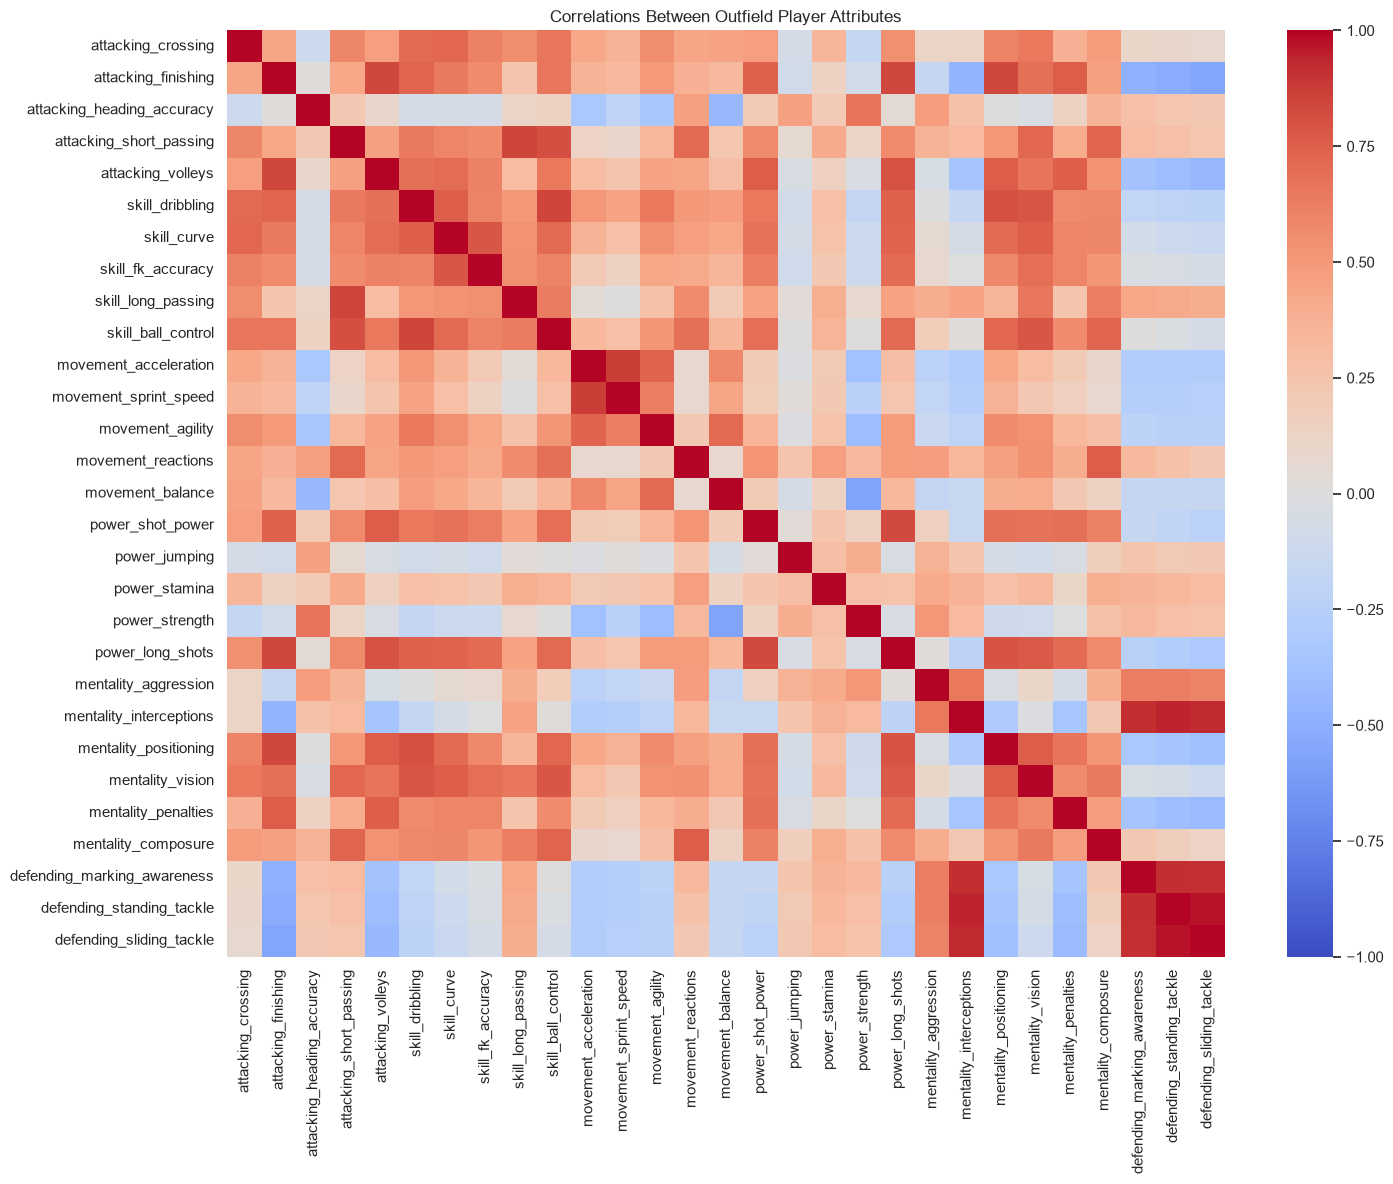

In [7]:
correlation_matrix = outfield_df[available_attributes].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlations Between Outfield Player Attributes")
plt.tight_layout()
plt.show()

In [8]:
correlation_pairs = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
).stack().sort_values(ascending=False)

print("Strongest positive correlations:")
display(correlation_pairs.head(15).to_frame("correlation"))

print("\nStrongest negative correlations:")
display(correlation_pairs.tail(15).to_frame("correlation"))

Strongest positive correlations:


correlation
defending_standing_tackle   defending_sliding_tackle        0.969148
mentality_interceptions     defending_standing_tackle       0.937554
                            defending_sliding_tackle        0.922042
                            defending_marking_awareness     0.917479
defending_marking_awareness defending_standing_tackle       0.916566
                            defending_sliding_tackle        0.908803
movement_acceleration       movement_sprint_speed           0.867931
skill_dribbling             skill_ball_control              0.848289
attacking_short_passing     skill_long_passing              0.844993
attacking_finishing         mentality_positioning           0.840949
                            power_long_shots                0.839819
                            attacking_volleys               0.837347
power_shot_power            power_long_shots                0.835717
attacking_short_passing     skill_ball_control              0.813681
skill_dribbling             mentality_positioning           0.809665


Strongest negative correlations:


,,correlation
mentality_positioning,defending_standing_tackle,-0.357796
attacking_volleys,defending_marking_awareness,-0.368363
movement_acceleration,power_strength,-0.376161
mentality_positioning,defending_sliding_tackle,-0.387348
mentality_penalties,defending_standing_tackle,-0.398729
attacking_volleys,defending_standing_tackle,-0.409393
movement_agility,power_strength,-0.409475
mentality_penalties,defending_sliding_tackle,-0.427867
attacking_heading_accuracy,movement_balance,-0.438747
attacking_volleys,defending_sliding_tackle,-0.442524


### Skill-correlation result

Several strong correlations indicate that the 29 observed skills can be represented by a smaller number of underlying abilities.

The strongest positive relationships occur among defensive attributes. Standing tackle and sliding tackle have a correlation of approximately **0.97**, while interceptions, marking, and both tackling variables also correlate above **0.90**. Acceleration and sprint speed are strongly related at approximately **0.87**.

Technical combinations are also visible: dribbling correlates strongly with ball control, short passing with long passing, and finishing with positioning, long shots, and volleys.

Negative correlations reveal role-based trade-offs. Finishing is negatively associated with tackling, marking, and interceptions, reflecting the contrast between attacking and defensive specialization. Balance and agility are also negatively related to strength, distinguishing lighter mobile players from more physically powerful profiles.

These relationships support the use of factor analysis to summarize the overlapping skill variables.

In [9]:
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

imputed_skills = imputer.fit_transform(outfield_df[available_attributes])
standardised_skills = scaler.fit_transform(imputed_skills)

print("Standardised matrix shape:", standardised_skills.shape)
print("Average feature mean:", standardised_skills.mean(axis=0).mean())
print("Average feature standard deviation:", standardised_skills.std(axis=0).mean())

Standardised matrix shape: (17107, 29)
Average feature mean: 2.4290933129796223e-17
Average feature standard deviation: 1.0


In [10]:
rng = np.random.default_rng(RANDOM_STATE)
sample_size = min(10000, len(standardised_skills))
sample_indices = rng.choice(len(standardised_skills), size=sample_size, replace=False)
analysis_sample = standardised_skills[sample_indices]

observed_eigenvalues = PCA().fit(analysis_sample).explained_variance_

In [11]:
N_RANDOM_DATASETS = 25
random_eigenvalues = []

for _ in range(N_RANDOM_DATASETS):
    random_data = rng.normal(size=analysis_sample.shape)
    random_eigenvalues.append(PCA().fit(random_data).explained_variance_)

random_eigenvalues = np.asarray(random_eigenvalues)
random_thresholds = np.percentile(random_eigenvalues, 95, axis=0)

parallel_analysis_df = pd.DataFrame({
    "component": np.arange(1, len(observed_eigenvalues) + 1),
    "observed_eigenvalue": observed_eigenvalues,
    "random_95th_percentile": random_thresholds,
    "retain": observed_eigenvalues > random_thresholds
})

parallel_analysis_df.head(15)

,component,observed_eigenvalue,random_95th_percentile,retain
0,1,11.514674,1.112843,True
1,2,6.451389,1.102790,True
2,3,2.922862,1.090672,True
3,4,1.753044,1.078534,True
4,5,0.748117,1.074702,False
5,6,0.671773,1.063368,False
6,7,0.555215,1.057509,False
7,8,0.446486,1.047586,False
8,9,0.416600,1.042351,False
9,10,0.397643,1.034128,False


In [12]:
suggested_factors = int(parallel_analysis_df["retain"].sum())
selected_factors = int(np.clip(suggested_factors, 4, 8))

print("Factors suggested by parallel analysis:", suggested_factors)
print("Factors selected for interpretation:", selected_factors)

Factors suggested by parallel analysis: 4
Factors selected for interpretation: 4


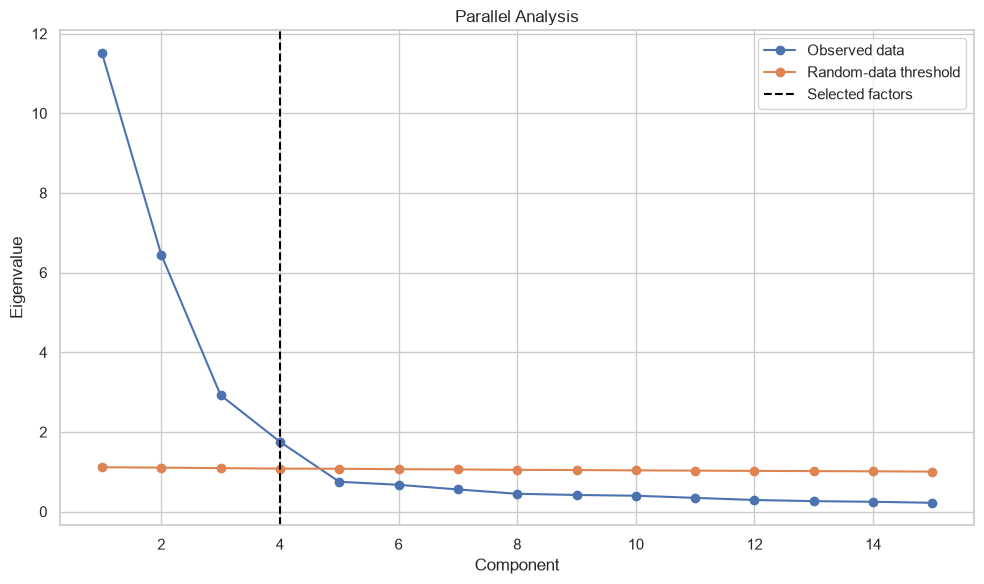

In [13]:
plot_limit = min(15, len(parallel_analysis_df))
plot_df = parallel_analysis_df.head(plot_limit)

plt.figure(figsize=(10, 6))
plt.plot(plot_df["component"], plot_df["observed_eigenvalue"], marker="o", label="Observed data")
plt.plot(plot_df["component"], plot_df["random_95th_percentile"], marker="o", label="Random-data threshold")
plt.axvline(selected_factors, color="black", linestyle="--", label="Selected factors")
plt.xlabel("Component")
plt.ylabel("Eigenvalue")
plt.title("Parallel Analysis")
plt.legend()
plt.tight_layout()
plt.show()

### Parallel analysis findings

Parallel analysis recommends retaining **four latent factors**.

The first four observed eigenvalues—approximately **11.51, 6.45, 2.92, and 1.75**—are all greater than their corresponding eigenvalues from randomly generated data. The fifth observed eigenvalue falls below the random-data threshold.

The clear crossover after the fourth component indicates that a four-factor model captures meaningful shared structure without retaining factors that are likely to represent sampling noise.

In [14]:
factor_model = FactorAnalysis(
    n_components=selected_factors, rotation="varimax",
    random_state=RANDOM_STATE, max_iter=2000
)

raw_factor_scores = factor_model.fit_transform(standardised_skills)
factor_loadings = factor_model.components_.T.copy()
factor_scores = raw_factor_scores.copy()

factor_names = [f"Factor {number}" for number in range(1, selected_factors + 1)]

In [15]:
for factor_index in range(selected_factors):
    strongest_loading = np.argmax(np.abs(factor_loadings[:, factor_index]))
    if factor_loadings[strongest_loading, factor_index] < 0:
        factor_loadings[:, factor_index] *= -1
        factor_scores[:, factor_index] *= -1

loadings_df = pd.DataFrame(factor_loadings, index=available_attributes, columns=factor_names)
scores_df = pd.DataFrame(factor_scores, columns=factor_names)

In [16]:
top_loading_rows = []

for factor in factor_names:
    top_features = loadings_df[factor].abs().nlargest(7).index
    for feature in top_features:
        top_loading_rows.append({
            "factor": factor,
            "feature": feature,
            "loading": loadings_df.loc[feature, factor]
        })

top_loadings_df = pd.DataFrame(top_loading_rows)
top_loadings_df

,factor,feature,loading
0,Factor 1,defending_standing_tackle,0.971978
1,Factor 1,defending_sliding_tackle,0.965128
2,Factor 1,mentality_interceptions,0.944455
3,Factor 1,defending_marking_awareness,0.925700
4,Factor 1,mentality_aggression,0.618021
5,Factor 1,skill_long_passing,0.506036
6,Factor 1,attacking_finishing,-0.469499
7,Factor 2,mentality_vision,0.884132
8,Factor 2,power_long_shots,0.870166
9,Factor 2,skill_ball_control,0.868322


### Factor loading findings

The rotated loadings support the following interpretations:

1. **Factor 1 – Defensive Ball-Winning**  
   This factor has very high loadings for standing tackle, sliding tackle, interceptions, and defensive awareness. Aggression and long passing also contribute, suggesting a combination of ball recovery and defensive distribution. Finishing loads negatively because attacking specialists generally have lower defensive involvement.

2. **Factor 2 – Technical Creation and Shooting**  
   Vision, long shots, ball control, curve, dribbling, shot power, and attacking positioning load strongly on this factor. It represents players who create chances, control the ball, and contribute technically around the attacking areas.

3. **Factor 3 – Explosive Pace and Mobility**  
   Acceleration and sprint speed have the strongest loadings, followed by agility and balance. This factor identifies fast, mobile players capable of covering space and changing direction quickly.

4. **Factor 4 – Aerial Physical Presence**  
   Heading accuracy, strength, and jumping define this factor. Aggression, reactions, and composure also contribute, while balance loads negatively. It represents physically imposing players suited to aerial contests, hold-up play, and central duels.

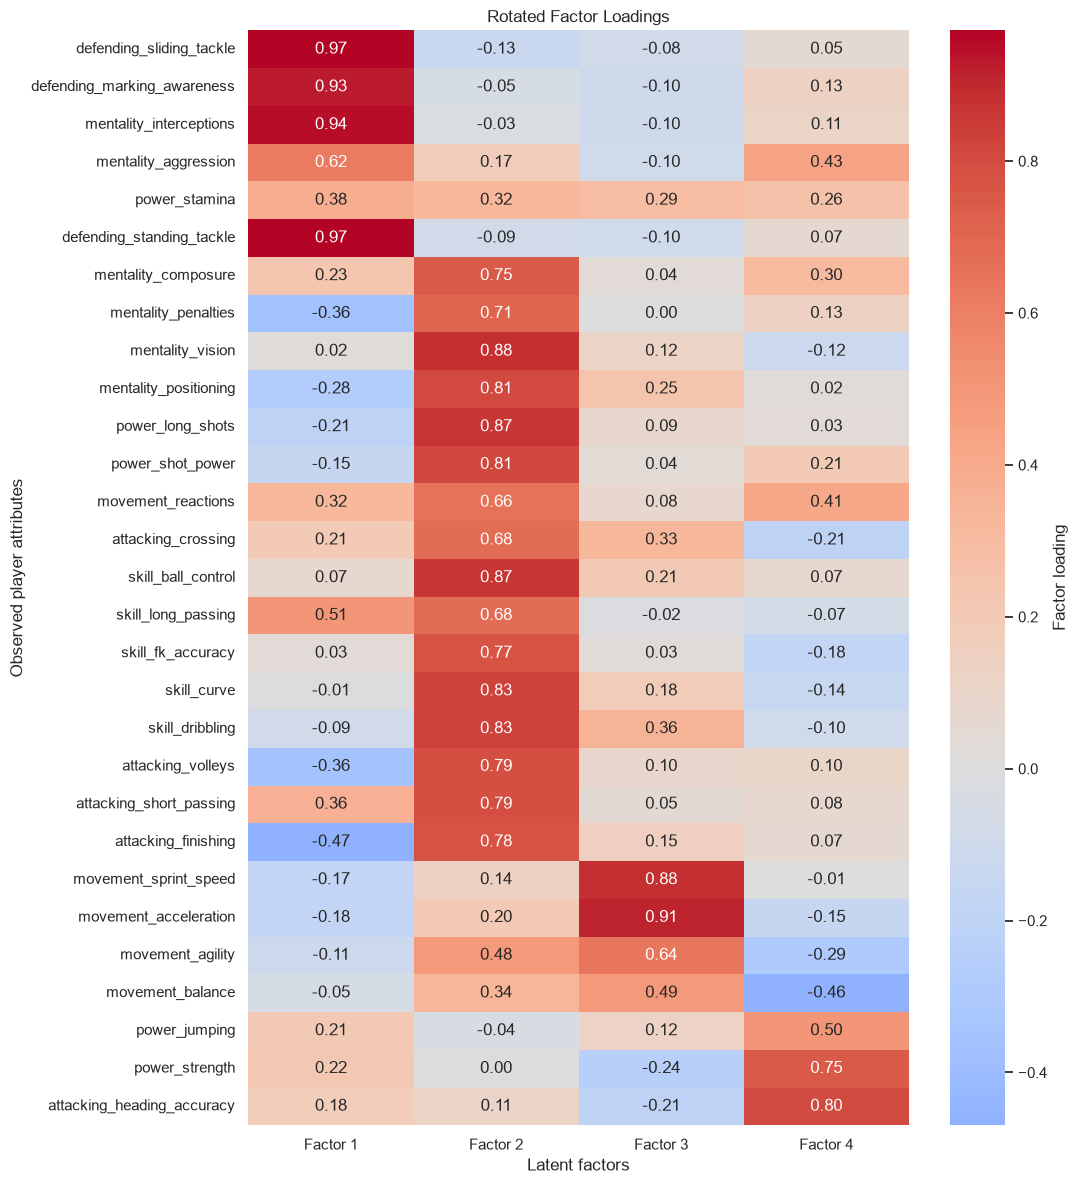

In [17]:
dominant_factor = loadings_df.abs().idxmax(axis=1)
loading_order = dominant_factor.sort_values().index

plt.figure(figsize=(11, 12))
sns.heatmap(
    loadings_df.loc[loading_order], cmap="coolwarm", center=0,
    annot=True, fmt=".2f", cbar_kws={"label": "Factor loading"}
)
plt.title("Rotated Factor Loadings")
plt.xlabel("Latent factors")
plt.ylabel("Observed player attributes")
plt.tight_layout()
plt.show()

In [18]:
factor_correlation_df = scores_df.corr()
factor_correlation_df

,Factor 1,Factor 2,Factor 3,Factor 4
Factor 1,1.000000,-0.002035,-0.004212,0.011637
Factor 2,-0.002035,1.000000,0.018603,0.013800
Factor 3,-0.004212,0.018603,1.000000,-0.036012
Factor 4,0.011637,0.013800,-0.036012,1.000000


### Factor structure interpretation

The four factors are distinct but still allow some attributes to contribute to multiple football abilities.

For example, aggression contributes to both defensive ball-winning and physical presence. Dribbling is mainly technical but also contributes to mobility, while balance is positively associated with mobility and negatively associated with the heavier physical profile.

The correlations between the estimated factor scores are all close to zero. This is consistent with the orthogonal Varimax rotation and indicates that the model produces four largely independent dimensions.

Players should therefore be interpreted using their complete factor profiles rather than being assigned to only one rigid playing type.

In [19]:
communalities = np.square(factor_loadings).sum(axis=1)

communality_df = pd.DataFrame({
    "feature": available_attributes,
    "communality": communalities,
    "uniqueness": factor_model.noise_variance_
}).sort_values("communality", ascending=False)

communality_df

,feature,communality,uniqueness
27,defending_standing_tackle,0.966188,0.033817
28,defending_sliding_tackle,0.957383,0.042614
10,movement_acceleration,0.923115,0.077016
21,mentality_interceptions,0.915635,0.084367
26,defending_marking_awareness,0.885976,0.114022
1,attacking_finishing,0.853367,0.146632
5,skill_dribbling,0.826551,0.173446
11,movement_sprint_speed,0.820604,0.179471
23,mentality_vision,0.812038,0.187875
19,power_long_shots,0.810891,0.189094


In [20]:
reconstructed_skills = raw_factor_scores @ factor_model.components_ + factor_model.mean_
reconstruction_rmse = np.sqrt(mean_squared_error(standardised_skills, reconstructed_skills))
average_communality = communalities.mean()

print(f"Average communality: {average_communality:.3f}")
print(f"Standardised reconstruction RMSE: {reconstruction_rmse:.3f}")

Average communality: 0.740
Standardised reconstruction RMSE: 0.485


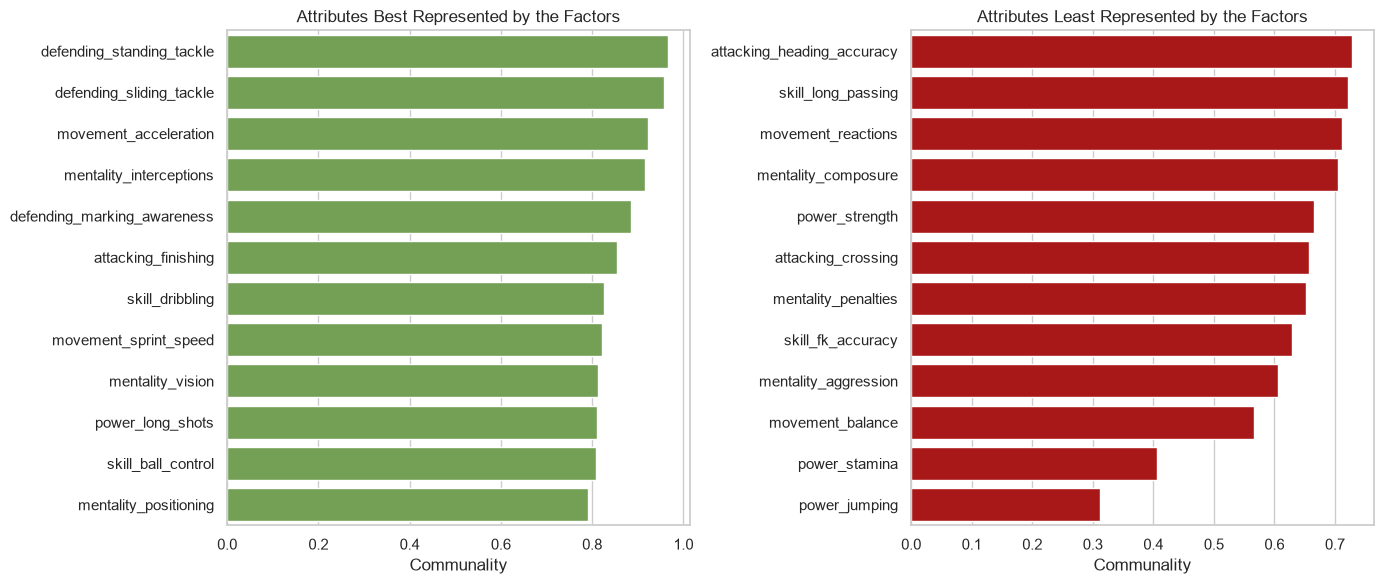

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=communality_df.head(12), x="communality", y="feature", color="#70AD47", ax=axes[0])
axes[0].set_title("Attributes Best Represented by the Factors")
axes[0].set_xlabel("Communality")
axes[0].set_ylabel("")

sns.barplot(data=communality_df.tail(12), x="communality", y="feature", color="#C00000", ax=axes[1])
axes[1].set_title("Attributes Least Represented by the Factors")
axes[1].set_xlabel("Communality")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Factor model evaluation

The four-factor solution achieves an average communality of approximately **0.74**. Therefore, the latent factors represent about 74% of the variance in an average skill variable.

Defensive tackling, interceptions, acceleration, finishing, dribbling, vision, and ball control are represented particularly well. Standing tackle has a communality of approximately **0.97**, while sliding tackle, acceleration, interceptions, and defensive awareness also exceed **0.88**.

Jumping and stamina have the lowest communalities, indicating that these attributes retain more skill-specific variation not fully captured by the four factors.

The reconstruction RMSE is approximately **0.49 standardized units**. This is a reasonable result for compressing 29 correlated skill variables into only four interpretable dimensions, although the model should be treated as a useful summary rather than a complete description of every player attribute.

In [22]:
player_factor_df = pd.concat(
    [outfield_df[available_metadata].reset_index(drop=True), scores_df.reset_index(drop=True)],
    axis=1
)

player_factor_df["primary_position"] = (
    player_factor_df["player_positions"].str.split(",").str[0].str.strip()
)

player_factor_df.head()

,short_name,long_name,age,nationality_name,club_name,player_positions,overall,potential,preferred_foot,Factor 1,Factor 2,Factor 3,Factor 4,primary_position
0,L. Messi,Lionel Andrés Messi Cuccittini,34,Argentina,Paris Saint-Germain,"RW, ST, CF",93,93,Left,-0.695595,3.311120,1.070911,0.487585,RW
1,R. Lewandowski,Robert Lewandowski,32,Poland,FC Bayern München,ST,92,92,Right,-0.790415,2.758313,0.487942,2.613889,ST
2,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,36,Portugal,Manchester United,"ST, LW",91,91,Right,-1.077436,2.693658,1.236743,2.521956,ST
3,Neymar Jr,Neymar da Silva Santos Júnior,29,Brazil,Paris Saint-Germain,"LW, CAM",91,91,Right,-0.589867,2.811046,1.575699,0.384455,LW
4,K. De Bruyne,Kevin De Bruyne,30,Belgium,Manchester City,"CM, CAM",91,91,Right,0.923838,3.212282,0.238317,0.255236,CM


In [23]:
def position_group(position):
    defenders = {"CB", "LB", "RB", "LWB", "RWB"}
    midfielders = {"CDM", "CM", "CAM", "LM", "RM"}
    attackers = {"ST", "CF", "LW", "RW", "LF", "RF", "LS", "RS"}

    if position in defenders:
        return "Defender"
    if position in midfielders:
        return "Midfielder"
    if position in attackers:
        return "Attacker"
    return "Other"

player_factor_df["position_group"] = player_factor_df["primary_position"].apply(position_group)
player_factor_df["position_group"].value_counts()

position_group
Midfielder    7033
Defender      6394
Attacker      3680
Name: count, dtype: int64

In [24]:
position_factor_means_df = (
    player_factor_df.groupby("position_group", observed=True)[factor_names]
    .mean().reindex(["Defender", "Midfielder", "Attacker", "Other"])
)

position_factor_means_df

,Factor 1,Factor 2,Factor 3,Factor 4
position_group,,,,
Defender,0.679448,-0.682303,0.018061,0.243370
Midfielder,0.078973,0.461197,-0.065093,-0.490616
Attacker,-1.331471,0.304089,0.093021,0.514781
Other,NaN,NaN,NaN,NaN


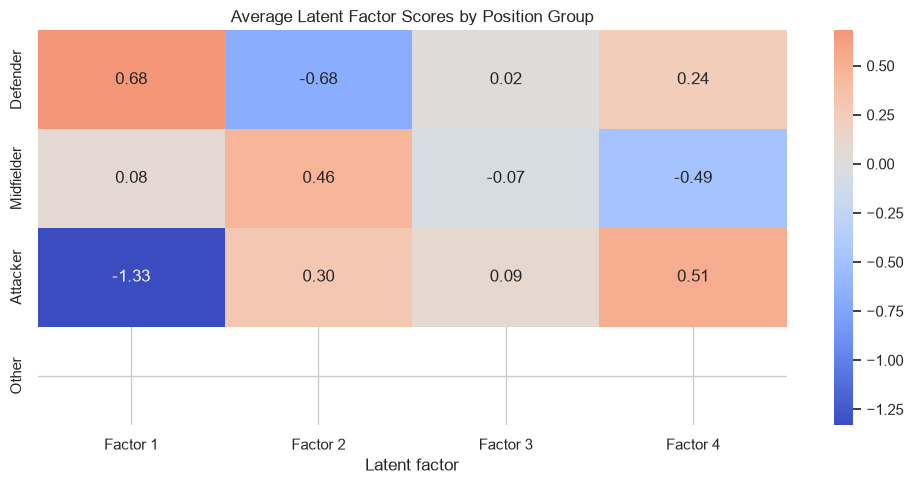

In [25]:
plt.figure(figsize=(10, 5))
sns.heatmap(position_factor_means_df, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Average Latent Factor Scores by Position Group")
plt.xlabel("Latent factor")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Position validation 

The position groups were used only after model fitting, providing an external validation of the discovered factors.

- **Defenders** have the highest average Defensive Ball-Winning score and a positive Aerial Physical Presence score.
- **Midfielders** have the highest average Technical Creation and Shooting score.
- **Attackers** have the highest average Aerial Physical Presence score, a positive technical-attacking score, and a strongly negative defensive score.
- Average Explosive Pace and Mobility scores are relatively similar across the broad position groups.

The limited difference in average pace does not mean that pace is unimportant. Instead, fast players occur in several positions, including fullbacks, wingers, and forwards, so their scores are diluted when players are combined into broad positional categories.

Overall, the positional patterns provide strong football-based support for the four factor interpretations.

In [26]:
exemplar_rows = []

for factor in factor_names:
    top_players = player_factor_df.nlargest(8, factor)
    for rank, (_, player) in enumerate(top_players.iterrows(), start=1):
        exemplar_rows.append({
            "factor": factor,
            "rank": rank,
            "player": player["short_name"],
            "positions": player["player_positions"],
            "club": player.get("club_name", np.nan),
            "overall": player["overall"],
            "factor_score": player[factor]
        })

factor_exemplars_df = pd.DataFrame(exemplar_rows)
factor_exemplars_df

,factor,rank,player,positions,club,overall,factor_score
0,Factor 1,1,N. Kanté,"CDM, CM",Chelsea,90,2.395562
1,Factor 1,2,Marquinhos,"CB, CDM",Paris Saint-Germain,87,2.250762
2,Factor 1,3,A. Wan-Bissaka,RB,Manchester United,83,2.209085
3,Factor 1,4,M. Verratti,"CM, CAM",Paris Saint-Germain,87,2.136280
4,Factor 1,5,V. van Dijk,CB,Liverpool,89,2.133960
5,Factor 1,6,A. Robertson,LB,Liverpool,87,2.094407
6,Factor 1,7,Sergio Ramos,CB,Paris Saint-Germain,88,2.083911
7,Factor 1,8,J. Kimmich,"CDM, RB",FC Bayern München,89,2.068353
8,Factor 2,1,L. Messi,"RW, ST, CF",Paris Saint-Germain,93,3.311120
9,Factor 2,2,J. Rodríguez,"RW, CAM, CM",Everton,81,3.249554


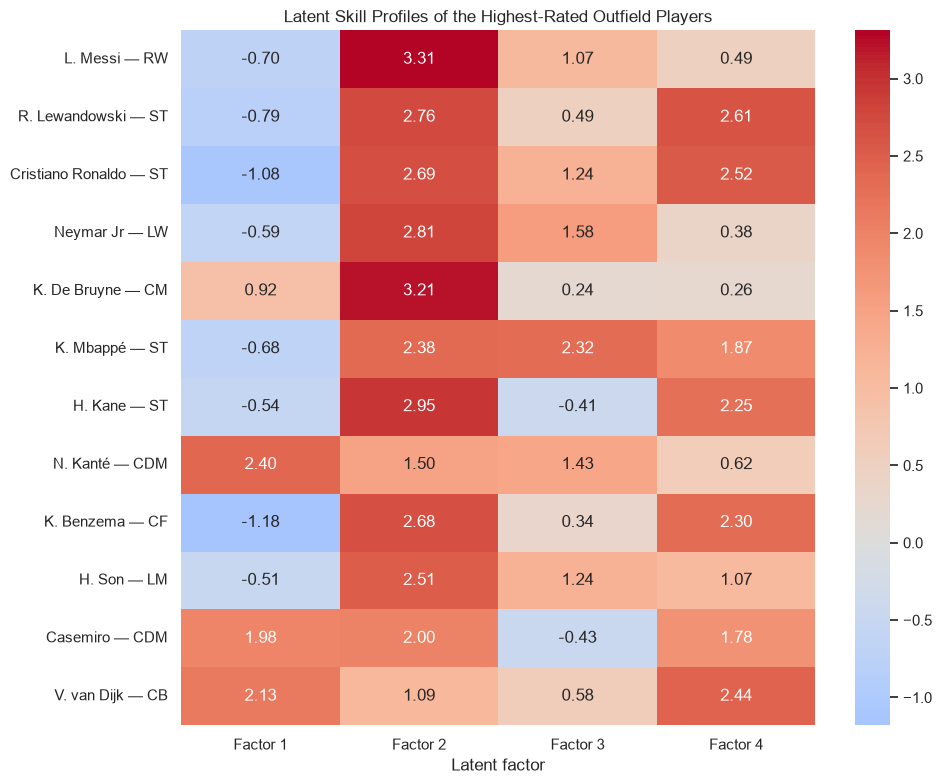

In [27]:
elite_profiles_df = player_factor_df.nlargest(12, "overall").copy()
elite_profiles_df["label"] = (
    elite_profiles_df["short_name"] + " — " + elite_profiles_df["primary_position"]
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    elite_profiles_df.set_index("label")[factor_names],
    cmap="coolwarm", center=0, annot=True, fmt=".2f"
)
plt.title("Latent Skill Profiles of the Highest-Rated Outfield Players")
plt.xlabel("Latent factor")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Player profile 

The highest-scoring players provide clear face validity for the factor labels.

- **Defensive Ball-Winning:** N'Golo Kanté, Marquinhos, Aaron Wan-Bissaka, Marco Verratti, Virgil van Dijk, Andrew Robertson, Sergio Ramos, and Joshua Kimmich.
- **Technical Creation and Shooting:** Lionel Messi, James Rodríguez, Toni Kroos, Parejo, Kevin De Bruyne, Bruno Fernandes, Harry Kane, and Raúl García.
- **Explosive Pace and Mobility:** Zaidu Sanusi, Alphonso Davies, Rico Henry, Achraf Hakimi, DeAndre Yedlin, Issa Kaboré, Adama Traoré, and Ruan.
- **Aerial Physical Presence:** Wout Weghorst, Henk Veerman, Duván Zapata, Andrea La Mantia, Romelu Lukaku, Dominic Calvert-Lewin, Moussa Marega, and Ante Budimir.

The elite-player comparison also demonstrates that factor scores are continuous and multidimensional. Messi is dominated by technical creation, while Mbappé combines technical quality, pace, and physical presence. Kanté combines exceptional defensive ability with useful mobility, and Van Dijk combines defensive and aerial-physical strengths.

The factors therefore describe player styles more effectively than mutually exclusive player categories.

In [28]:
player_factor_df["dominant_factor"] = player_factor_df[factor_names].idxmax(axis=1)

dominance_table_df = pd.crosstab(
    player_factor_df["position_group"],
    player_factor_df["dominant_factor"],
    normalize="index"
).reindex(["Defender", "Midfielder", "Attacker", "Other"])

dominance_table_df

dominant_factor,Factor 1,Factor 2,Factor 3,Factor 4
position_group,,,,
Defender,0.459337,0.023616,0.248358,0.268689
Midfielder,0.291199,0.430400,0.246268,0.032134
Attacker,0.001902,0.218478,0.297826,0.481793
Other,NaN,NaN,NaN,NaN


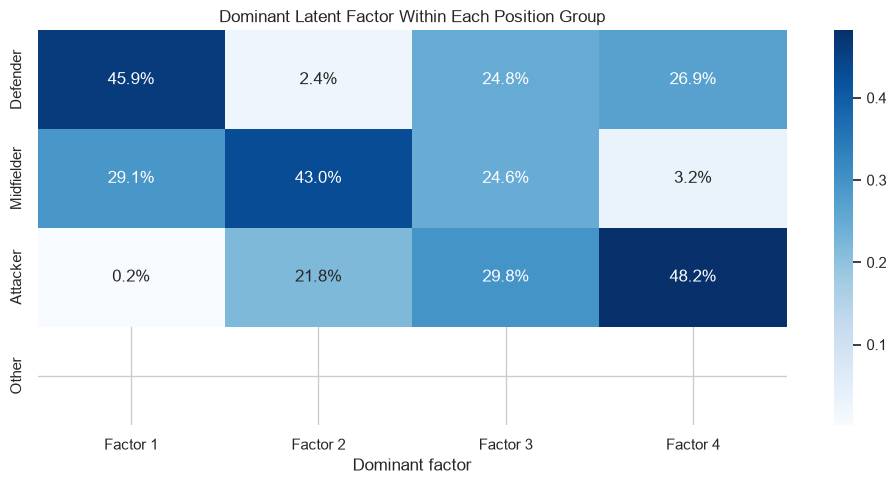

In [29]:
plt.figure(figsize=(10, 5))
sns.heatmap(dominance_table_df, cmap="Blues", annot=True, fmt=".1%")
plt.title("Dominant Latent Factor Within Each Position Group")
plt.xlabel("Dominant factor")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Factor dominance 

The dominant-factor comparison reveals meaningful variation within each broad position.

Approximately **46% of defenders** are dominated by Defensive Ball-Winning. However, about 25% are dominated by pace and 27% by aerial physical presence, reflecting differences between defensive midfield-style players, fast fullbacks, and physically dominant centre-backs.

Around **43% of midfielders** are dominated by Technical Creation and Shooting. Defensive and pace-dominant midfielders are also common, representing holding midfielders and wide midfield players.

Among attackers, approximately **48%** are dominated by Aerial Physical Presence, **30%** by pace, and **22%** by technical creation. Defensive dominance is almost absent, as expected.

Dominant-factor labels provide a convenient summary, but they discard information from the remaining scores. Complete factor profiles should be used when comparing players with balanced or hybrid playing styles.

## Conclusion

Exploratory factor analysis reduced **29 correlated outfield skills into four interpretable latent dimensions**:

1. Defensive Ball-Winning  
2. Technical Creation and Shooting  
3. Explosive Pace and Mobility  
4. Aerial Physical Presence  

Parallel analysis supported retaining four factors, and the solution represented approximately **74% of the variance in an average skill attribute**. Position-level patterns and leading player examples strongly supported the football interpretation of the factors.

The analysis demonstrates that player ability cannot be represented adequately by a single overall rating or a fixed position label. Factor profiles provide a more informative description of how a player contributes, allowing players to be compared through combinations of defensive, technical, physical, and mobility-related strengths.

The model remains exploratory and is based on FIFA ratings rather than direct match-performance measurements. Nevertheless, it provides a compact and interpretable framework for player profiling, scouting comparisons, similarity analysis, and squad-composition research.